In [1]:
import pandas as pd

In [68]:
import numpy as np

df_matches = pd.read_csv('../../data/preprocessed/preprocessed_1.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)
season_labels, _ = pd.factorize(df_matches['result_match'])
feature_cols = [col for col in df_matches.columns if col not in
                ["match_api_id", "result_match", "stage", "season" ,"date", "home_team", "away_team"]]

df_matches = df_matches[feature_cols]
df_matches = df_matches.filter(like="home")
df_matches

,points_home,home_last_team_goal,home_last_team_shoton,home_last_team_possession,team_strength_home,team_aggression_home,team_acceleration_home,goal_conversion_rate_home,rolling_avg_goals_home,rolling_stability_goal_home,rolling_avg_goals_conversion_rate_home,rolling_stability_goals_conversion_rate_home,rolling_avg_shoton_home,rolling_stability_shoton_home
0,3,1.00,12.0,34.0,78.318182,70.833333,80.939394,0.083333,1.000000,NaN,0.083333,NaN,12.0,NaN
1,3,1.00,7.0,47.0,63.924242,45.484848,82.136364,0.142857,1.000000,NaN,0.142857,NaN,7.0,NaN
2,3,3.00,5.0,53.0,71.318182,73.590909,70.136364,0.600000,3.000000,NaN,0.600000,NaN,5.0,NaN
3,4,1.00,5.0,47.0,63.318182,62.500000,74.590909,0.200000,1.000000,NaN,0.200000,NaN,5.0,NaN
4,3,2.00,5.0,48.0,77.030303,76.909091,80.969697,0.400000,2.000000,NaN,0.400000,NaN,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,44,1.00,4.0,44.0,72.327273,70.127273,73.800000,0.250000,1.200000,0.447214,0.535714,0.819874,5.2,2.683282
2971,49,2.00,5.0,53.0,65.445455,51.818182,74.463636,0.400000,2.466667,0.869227,0.487619,0.062142,5.0,1.224745
2972,68,2.00,7.0,31.0,70.627273,78.036364,73.400000,0.285714,1.900000,0.894427,0.252857,0.108515,8.4,3.781534
2973,34,1.75,6.0,50.0,79.690909,78.727273,74.890909,0.291667,1.750000,0.829156,0.691667,0.424510,3.6,2.302173


<Figure size 1500x1500 with 0 Axes>

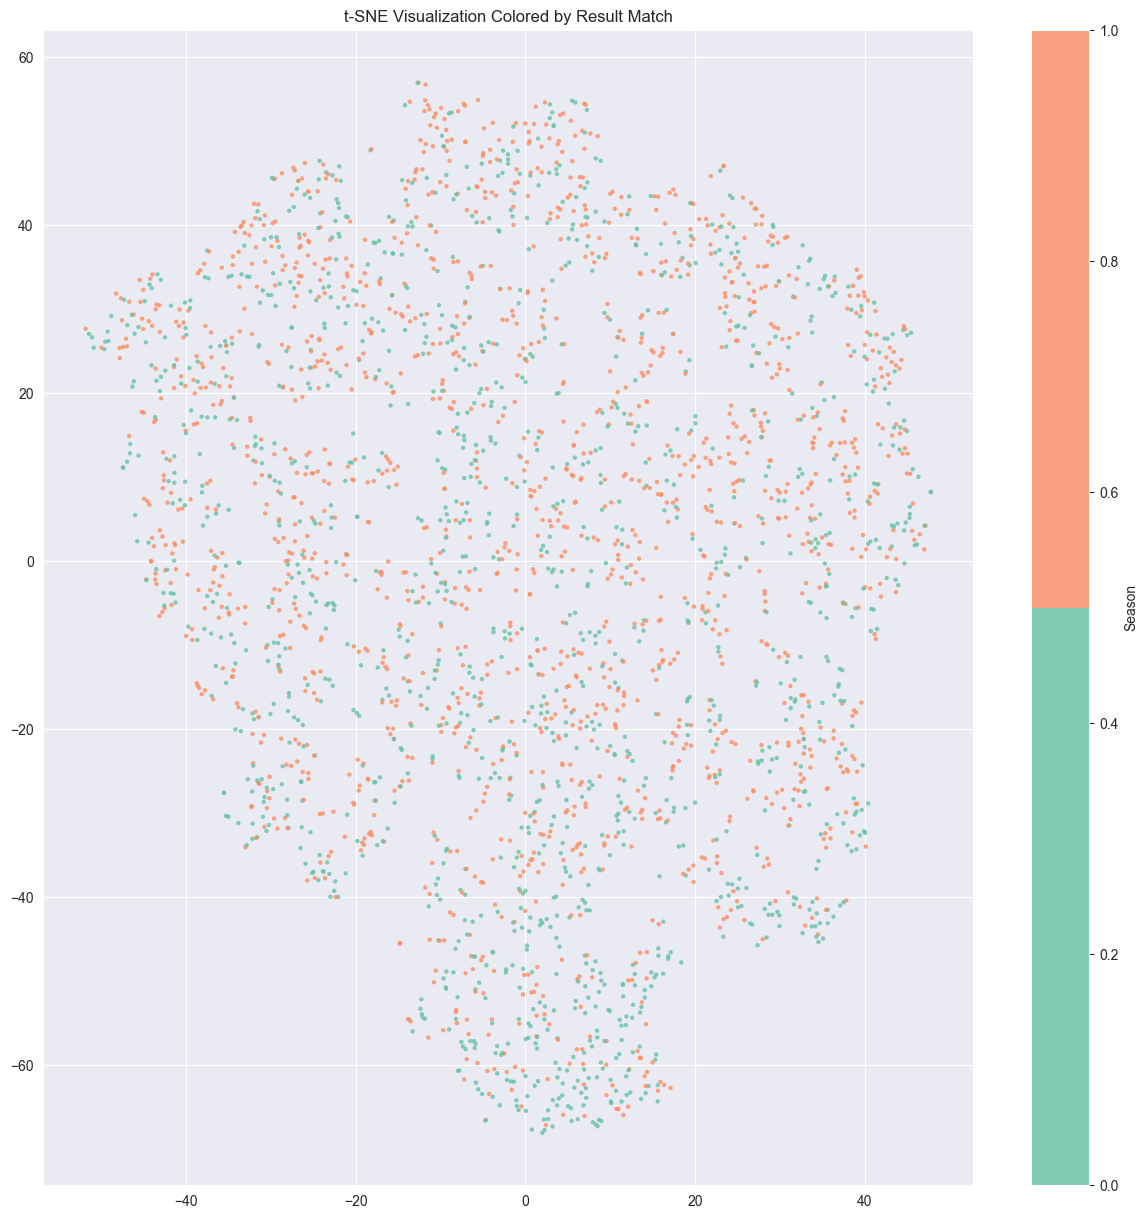

In [69]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

tsne = TSNE(n_components=2, perplexity=30., init="random", learning_rate="auto", random_state=42)
X = df_matches.fillna(df_matches.mean())
projection_2D = tsne.fit_transform(X)

palette = sns.color_palette("Set2", n_colors=len(set(season_labels)))
cmap = ListedColormap(palette)
plt.figure(figsize=(15, 15))
plt.figure(figsize=(15, 15))
plt.scatter(projection_2D[:, 0], projection_2D[:, 1], c=season_labels, cmap=cmap, edgecolor='none', alpha=0.80, s=10)
plt.colorbar(label="Season")
plt.title("t-SNE Visualization Colored by Result Match")
plt.show()
plt.show()